In [2]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.path.join(os.getcwd(), "plots")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Oscillations and stable up and down

In [3]:
aln = ALNModel()
N = aln.params.N

aln.params.mufe_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.mufi_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.seem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.seiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.rates_exc_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.rates_inh_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.IA_init = 0.0 * np.random.uniform(0, 1, (N, 1))  # pA

aln.params.sigma_ou = 0.
aln.params.mue_ou = np.array( [0.] )
aln.params.mui_ou = np.array( [0.] )

state_vars = aln.state_vars
init_vars = aln.init_vars

def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
                    
def set_params_slow():
    # external currents for aE limit cycle (slow)
    aln.params.ext_exc_current = 4.
    aln.params.ext_inh_current = 2.
    
def set_params_fast():
    # external currents for EI limit cycle (fast)
    aln.params.ext_exc_current = 2.5
    aln.params.ext_inh_current = 0.
    
def set_params_up():
    # external currents for up state
    aln.params.ext_exc_current = 5.
    aln.params.ext_inh_current = 1.
    
def set_params_down():
    # external currents for down state
    aln.params.ext_exc_current = 2.
    aln.params.ext_inh_current = 3.

In [4]:
aln.params.duration = 800.
aln.params.mue_ext_mean = 0.0
aln.params.mui_ext_mean = 0.0

control0 = aln.getZeroControl()

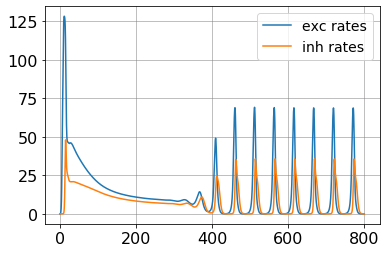

In [5]:
set_params_fast()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

fast_osc_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        fast_osc_init[i] = aln.state[state_vars[i]][0]
    else:
        fast_osc_init[i] = aln.state[state_vars[i]][0,-1]

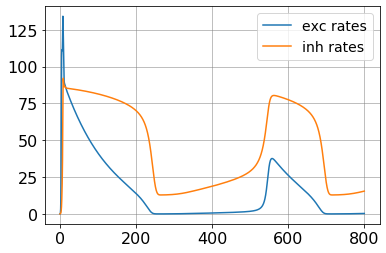

In [6]:
set_params_slow()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

slow_osc_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        slow_osc_init[i] = aln.state[state_vars[i]][0]
    else:
        slow_osc_init[i] = aln.state[state_vars[i]][0,-1]

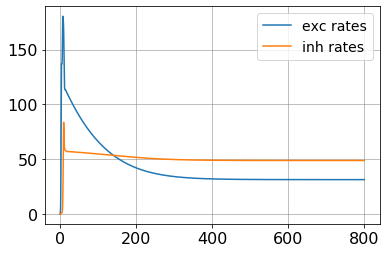

[31.3076 48.768 ]


In [7]:
set_params_up()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

up_rates = np.zeros((2))
up_rates[0] = aln.rates_exc[0,-1]
up_rates[1] = aln.rates_inh[0,-1]

print(up_rates)

up_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        up_init[i] = aln.state[state_vars[i]][0]
    else:
        up_init[i] = aln.state[state_vars[i]][0,-1]

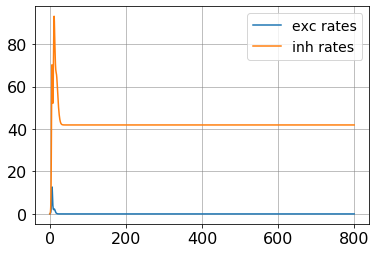

[4.4580e-10 4.1918e+01]


In [8]:
set_params_down()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

down_rates = np.zeros((2))
down_rates[0] = aln.rates_exc[0,-1]
down_rates[1] = aln.rates_inh[0,-1]

print(down_rates)

down_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        down_init[i] = aln.state[state_vars[i]][0]
    else:
        down_init[i] = aln.state[state_vars[i]][0,-1]

# A: Scenarios

scenario | control variables | precision measure
---------|--------------|-----------
A.0 | 0 | 0
B.1 | 1 | 1
B.2 | 2 | 0
B.3 | 0 | 1
B.4 | 1 | 0
B.5 | 2 | 1
B.6 | 0, 1 | 0
B.7 | 0, 1 | 1
B.8 | 0, 2 | 0
B.9 | 0, 2 | 1
B.10 | 1, 2 | 0
B.11 | 1, 2 | 1
B.12 | 0, 1, 2 | 0
B.13 | 0, 1, 2 | 1
B.14 | 0 | 0,1
B.15 | 1 | 0,1
B.16 | 2 | 0,1
B.17 | 0,1 | 0,1
B.18 | 0,2 | 0,1
B.19 | 1,2 | 0,1
B.20 | 0,1,2 | 0,1

In [9]:
max_c_c = 5.
min_c_c = - 5.
max_c_r = 0.18
min_c_r = 0.

def setmaxmincontrol(cntrl_vars):
    max_cntrl = np.zeros(( 4 ))
    min_cntrl = np.zeros(( 4 ))
    if cntrl_vars == [0]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
    elif cntrl_vars == [1]:
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
    elif cntrl_vars == [2]:
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
    elif cntrl_vars == [0,1]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
    elif cntrl_vars == [0,2]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
    elif cntrl_vars == [1,2]:
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
    elif cntrl_vars == [0,1,2]:
        max_cntrl[0] = max_c_c
        min_cntrl[0] = min_c_c
        max_cntrl[1] = max_c_c
        min_cntrl[1] = min_c_c
        max_cntrl[2] = max_c_r
        min_cntrl[2] = min_c_r
            
    return max_cntrl, min_cntrl        

In [10]:
dur = 600
dur_pre = 100
dur_post = 100
aln.params.duration = dur

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

set_params_fast()
setinit(fast_osc_init)

aln.run(control = aln.getZeroControl())
fast_rates = np.array( [aln.rates_exc[0,:], aln.rates_inh[0,:]] )

# set slow oscillation as target
target = aln.getZeroTarget()
target[0,0,:] = fast_rates[0,:]
target[0,1,:] = fast_rates[1,:]

In [11]:
c_var = [ [0], [1], [2], [0], [1], [2],
         [0,1], [0,1], [0,2], [0,2], [1,2], [1,2],
         [0,1,2], [0,1,2],
         [0], [1], [2], [0,1], [0,2], [1,2], [0,1,2] ]
p_var = [ [0], [1], [0], [1], [0], [1],
         [0], [1], [0], [1], [0], [1],
         [0], [1],
         [0,1], [0,1], [0,1], [0,1], [0,1], [0,1], [0,1] ]

max_it = 500

set_params_down()
initVars = down_init

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

trans_time_array = [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 
                    0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5 ]

sheet = "D_a_"

## 14

set cost params
control input:  [0] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  81410.97810861089
RUN  1 , total integrated cost =  28220.93099366349
RUN  2 , total integrated cost =  8706.32167774579
RUN  3 , total integrated cost =  2942.1730867898946
RUN  4 , total integrated cost =  2055.3854158559902
RUN  5 , total integrated cost =  1758.7461694504257
RUN  6 , total integrated cost =  1592.0502502635104
RUN  7 , total integrated cost =  1470.0688329324387
RUN  8 , total integrated cost =  1370.7611869690013
RUN  9 , total integrated cost =  1288.4889763714507
RUN  10 , total integrated cost =  1217.0146462720222
RUN  11 , total integrated cost =  1156.1269947954322
RUN  12 , total integrated cost =  1098.9693667943407
RUN  13 , total integrated cost =  1052.3125832533897
RUN  14 , total integrated cost =  1012.967106903134
RUN  15 , total integrated cost =  978.9255538756918
RUN  16 , total integrated cost =  949.6227338166051

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  5000 , total integrated cost =  22.98316590463019
RUN  5000 , total integrated cost =  22.98316590463019
Improved over  5000  iterations by  99.97176895986439  percent.
Problem in initial value trasfer:  Vmean_exc -80.81091189200119 -80.81091170625069
Problem in initial value trasfer:  Vmean_exc -56.72811595871975 -56.75798610843452


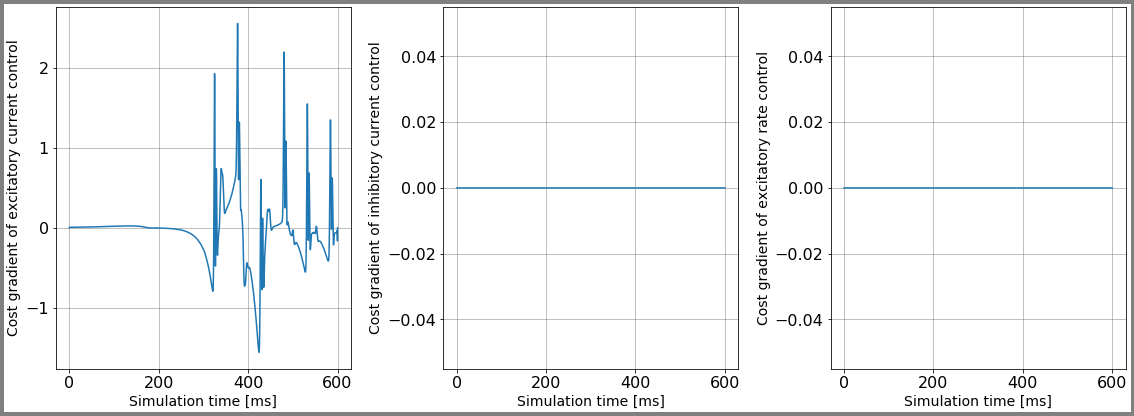

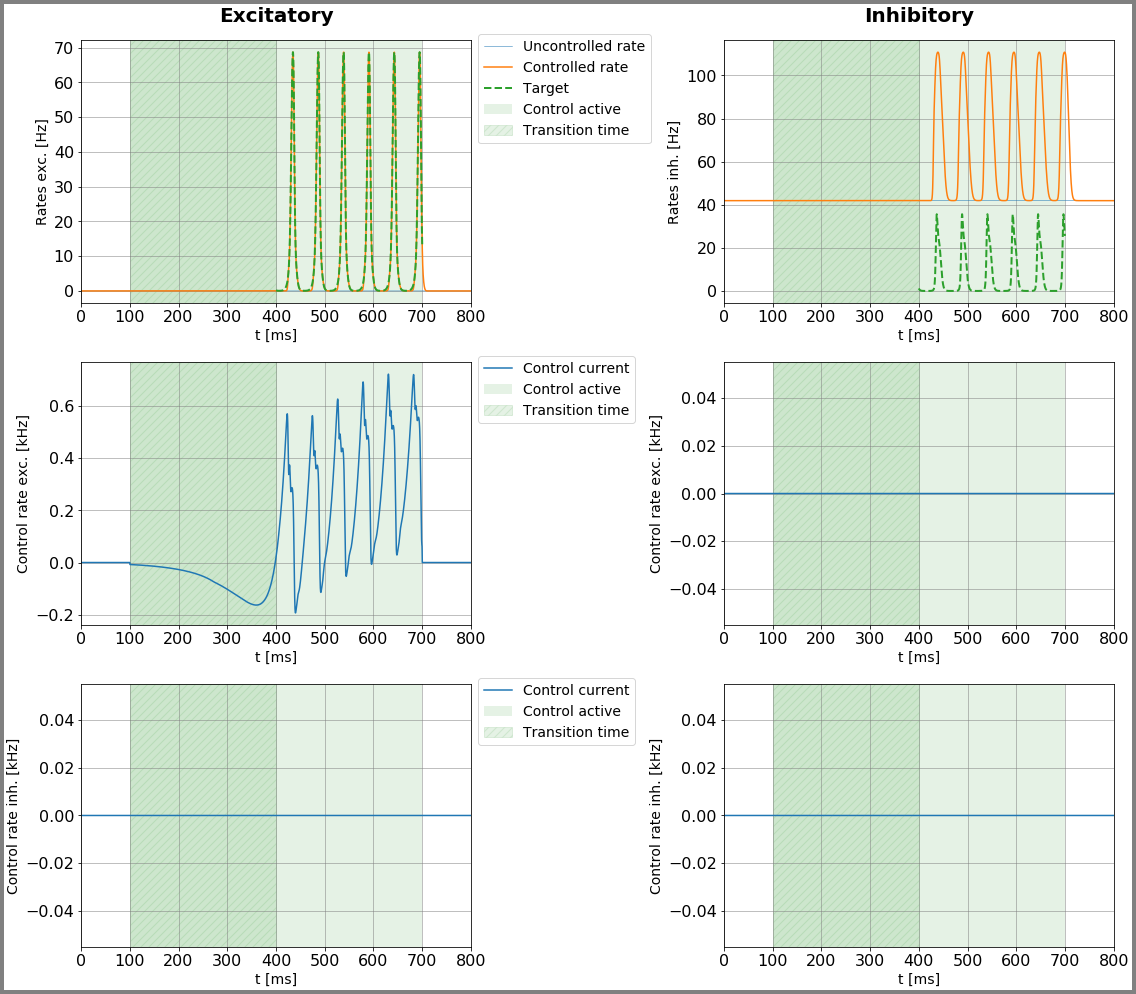

In [11]:
case_ind = 14
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  81410.97810861089
RUN  1 , total integrated cost =  28220.931610818472
RUN  2 , total integrated cost =  8706.32229481708
RUN  3 , total integrated cost =  2942.1736793861833
RUN  4 , total integrated cost =  2055.3860040376558
RUN  5 , total integrated cost =  1758.7467582346965
RUN  6 , total integrated cost =  1592.0508373578618
RUN  7 , total integrated cost =  1470.06941868481
RUN  8 , total integrated cost =  1370.7617730016482
RUN  9 , total integrated cost =  1288.489561107307
RUN  10 , total integrated cost =  1217.0152334724692
RUN  11 , total integrated cost =  1156.1275790690697
RUN  12 , total integrated cost =  1098.9699523534716
RUN  13 , total integrated cost =  1052.3131666391146
RUN  14 , total integrated cost =  1012.9676909575659
RUN  15 , total integrated cost =  978.9261365296228
RUN  16 , total integrated cost =  949.6233172514089
RUN  17 , total integrated cost =  923.1875817

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  5000 , total integrated cost =  23.075887207737956
RUN  5000 , total integrated cost =  23.075887207737956
Improved over  5000  iterations by  99.97165506698992  percent.
Problem in initial value trasfer:  Vmean_exc -80.81091189200119 -80.81091170625069
Problem in initial value trasfer:  Vmean_exc -56.728130665153856 -56.75799867570922


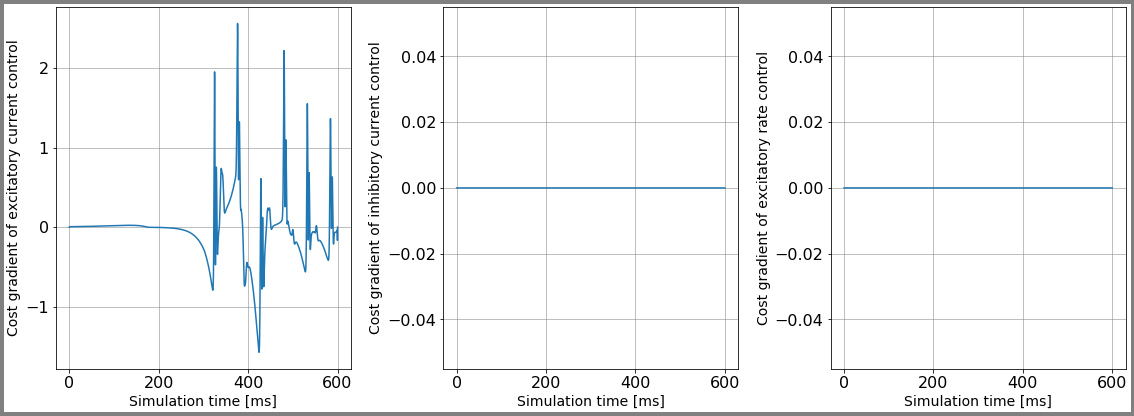

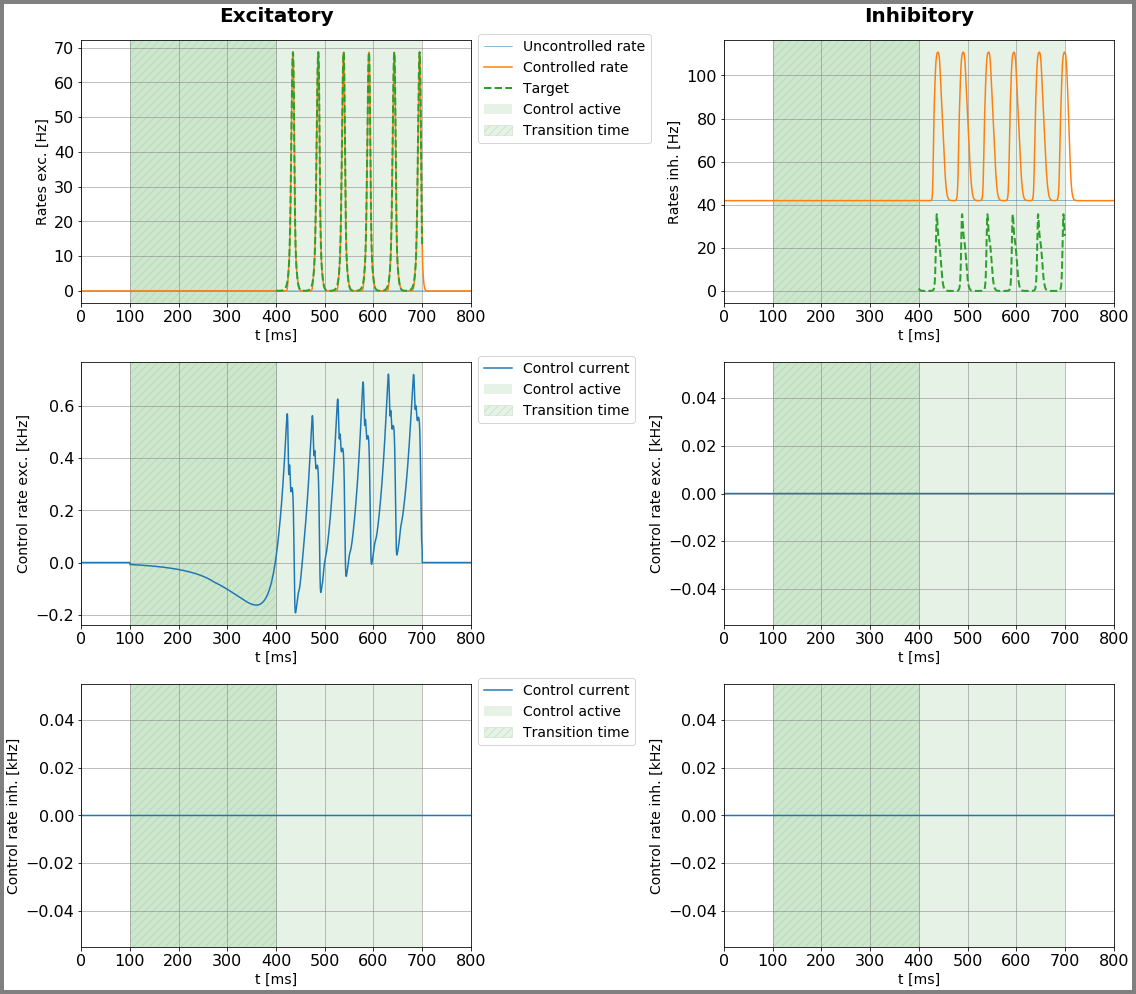

In [12]:
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case_ind = 14
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 1e-6, 1e-6)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 15

set cost params
control input:  [2] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  81410.97810861089
RUN  1 , total integrated cost =  64972.81511331574
RUN  2 , total integrated cost =  64230.5552078392
RUN  3 , total integrated cost =  64080.889351701946
RUN  4 , total integrated cost =  63448.13684818433
RUN  5 , total integrated cost =  63379.88756363284
RUN  6 , total integrated cost =  63002.985612556535
RUN  7 , total integrated cost =  62861.65628926248
RUN  8 , total integrated cost =  62638.754078799815
RUN  9 , total integrated cost =  62611.77808737385
RUN  10 , total integrated cost =  62073.71197074735
RUN  11 , total integrated cost =  62064.122485859516
RUN  12 , total integrated cost =  62052.66194511501
RUN  13 , total integrated cost =  62018.51398505066
RUN  14 , total integrated cost =  62009.64466176901
RUN  15 , total integrated cost =  62003.60145680947
RUN  16 , total integrated cost =  61993.50470385906
RUN  1

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  97 , total integrated cost =  61930.95948929683
Improved over  97  iterations by  23.927999726677697  percent.
Problem in initial value trasfer:  Vmean_exc -80.81091189200119 -80.81091170625069
Problem in initial value trasfer:  Vmean_exc -60.29193357923447 -60.320055438837144


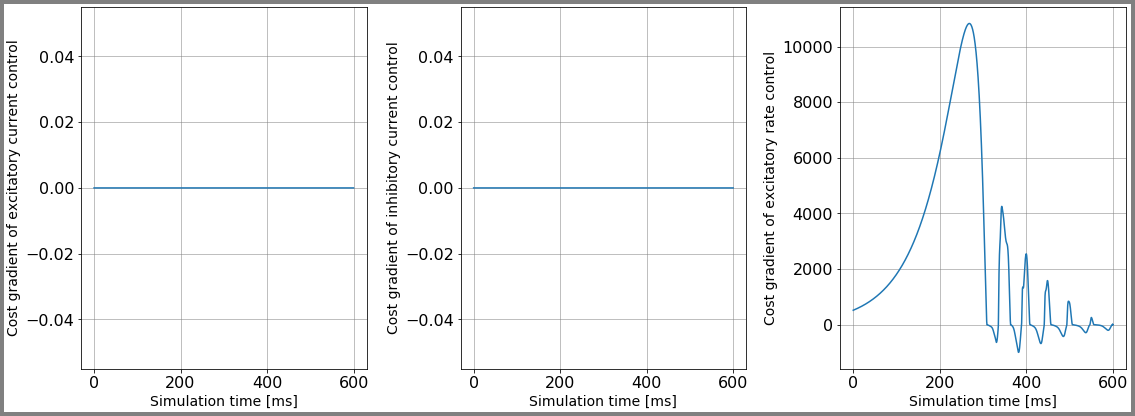

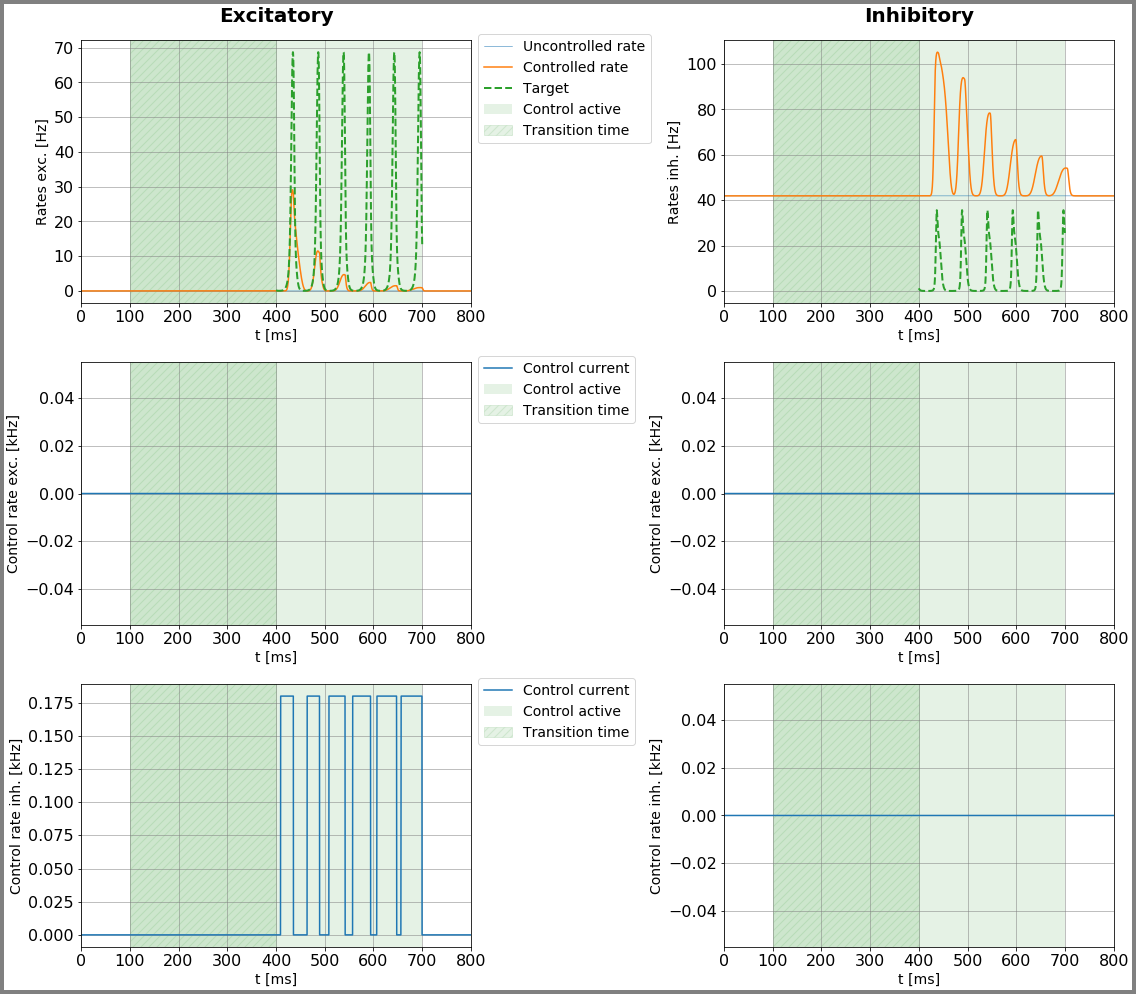

In [13]:
case_ind = 15
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

In [ ]:
case_ind = 15
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 1e-2, 1e-2)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 16

set cost params
control input:  [1] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  81410.97810861089


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  81410.97810861089
Control only changes marginally.
RUN  1 , total integrated cost =  81410.97810861089
Improved over  1  iterations by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -80.81091189200119 -80.81091170625069


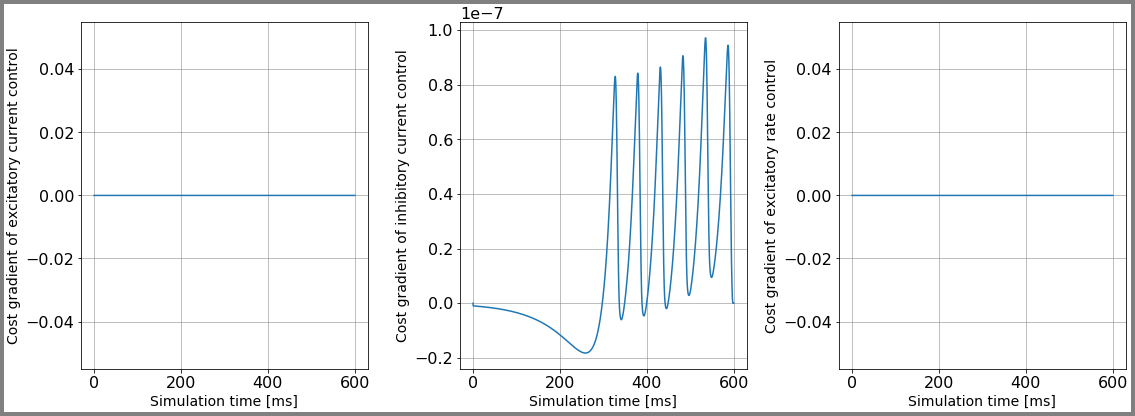

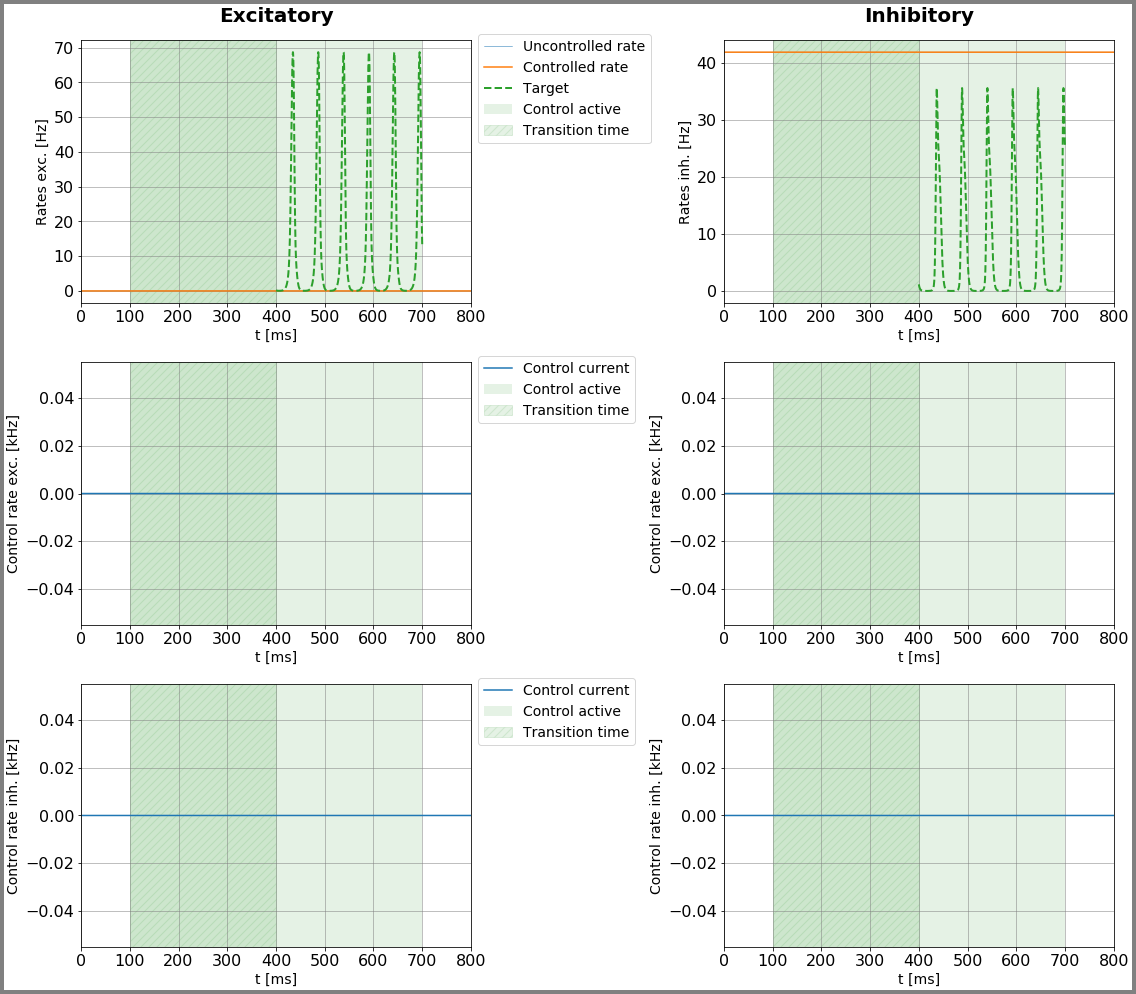

In [15]:
# A.4.a)

case_ind = 16
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  81410.97810861089


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  81410.97810861089
Control only changes marginally.
RUN  1 , total integrated cost =  81410.97810861089
Improved over  1  iterations by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -80.81091189200119 -80.81091170625069


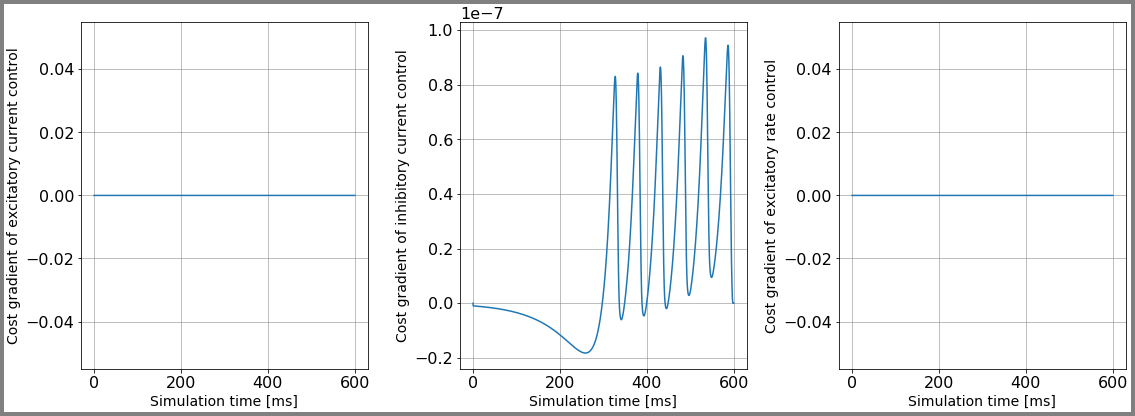

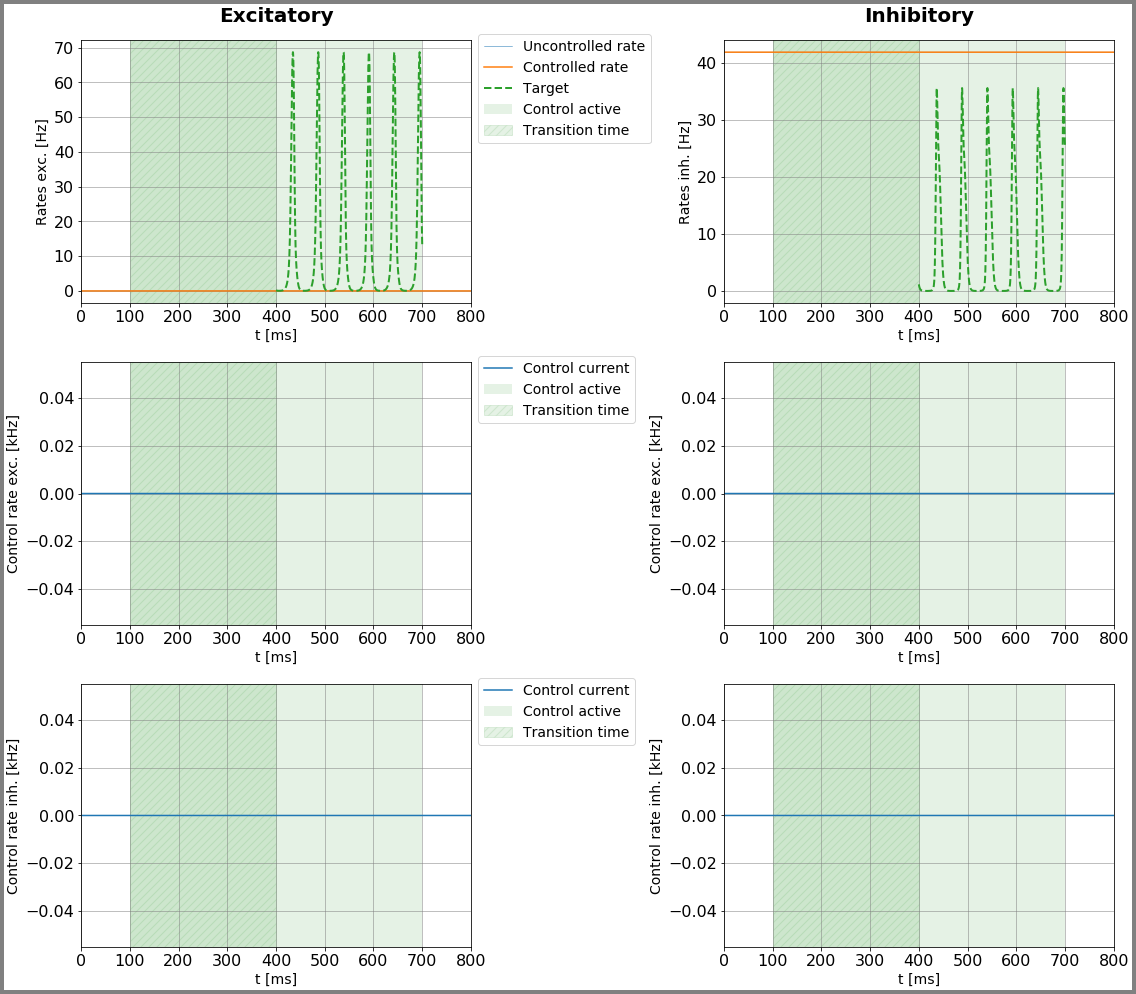

In [16]:
case_ind = 16
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 30.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 17

set cost params
control input:  [0, 1] , precision measure:  [0, 1]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.016391603330089547
Gradient descend method:  WYL
RUN  1 , total integrated cost =  0.016384184576375006


D:\Promotion\neurolib\neurolib\utils\func_optimize.py:476: RuntimeWarning: invalid value encountered in double_scalars
  numerator = np.dot( grad1_[n,v,:], grad1_[n,v,:] - grad0_[n,v,:] * ( g1abs / g0abs ) )


RUN  2 , total integrated cost =  0.016332761413285986
RUN  3 , total integrated cost =  0.01631436420649231
RUN  4 , total integrated cost =  0.016307647674243305
RUN  5 , total integrated cost =  0.016296681852338065
RUN  6 , total integrated cost =  0.016290987859303715
RUN  7 , total integrated cost =  0.016288032968334455
RUN  8 , total integrated cost =  0.01627748626385822
RUN  9 , total integrated cost =  0.016272408916001208
RUN  10 , total integrated cost =  0.01626393998752811
RUN  11 , total integrated cost =  0.016261509305752656
RUN  12 , total integrated cost =  0.016255690361715966
RUN  13 , total integrated cost =  0.016246789911207076
RUN  14 , total integrated cost =  0.016236844905404696
RUN  15 , total integrated cost =  0.016210767541937413
RUN  16 , total integrated cost =  0.01620637656073494
RUN  17 , total integrated cost =  0.01619574507667339
RUN  18 , total integrated cost =  0.016194017659916633
RUN  19 , total integrated cost =  0.016174910889946385
RUN  

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  100 , total integrated cost =  0.015554497501765175
RUN  100 , total integrated cost =  0.015554497501765175
Improved over  100  iterations in  25.354706199999782  seconds by  5.106918533025535  percent.
Problem in initial value trasfer:  Vmean_exc -80.81091189200119 -80.81091170625069
Problem in initial value trasfer:  Vmean_exc -56.76041957973496 -56.779835641954705


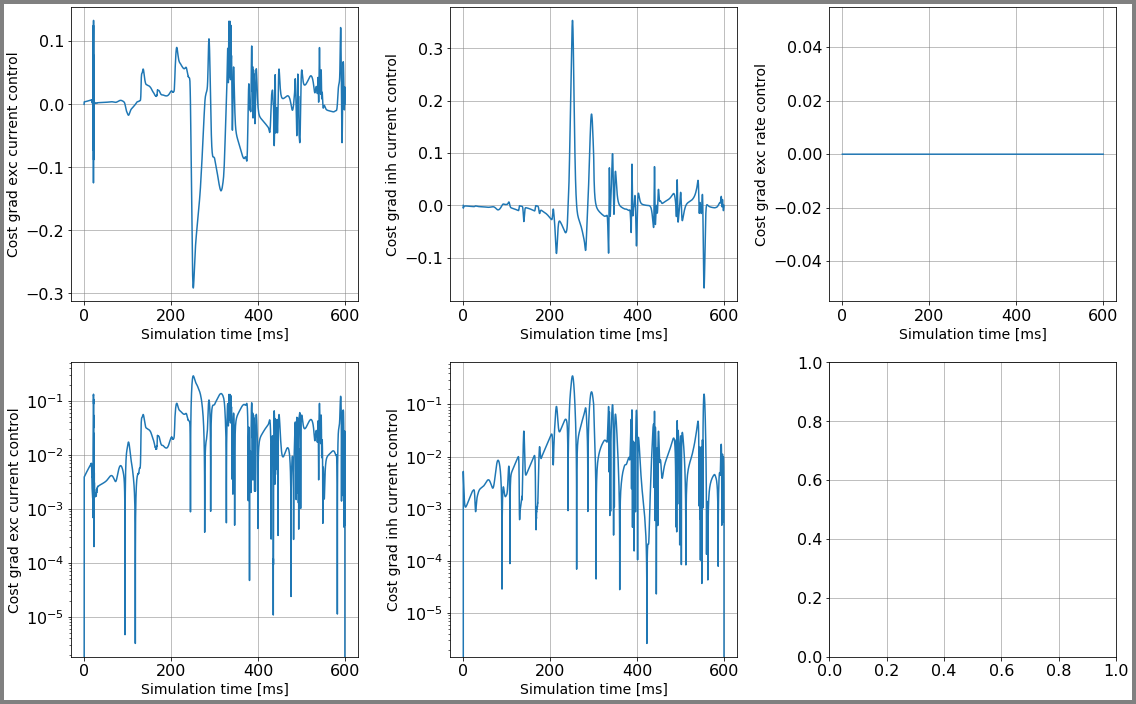

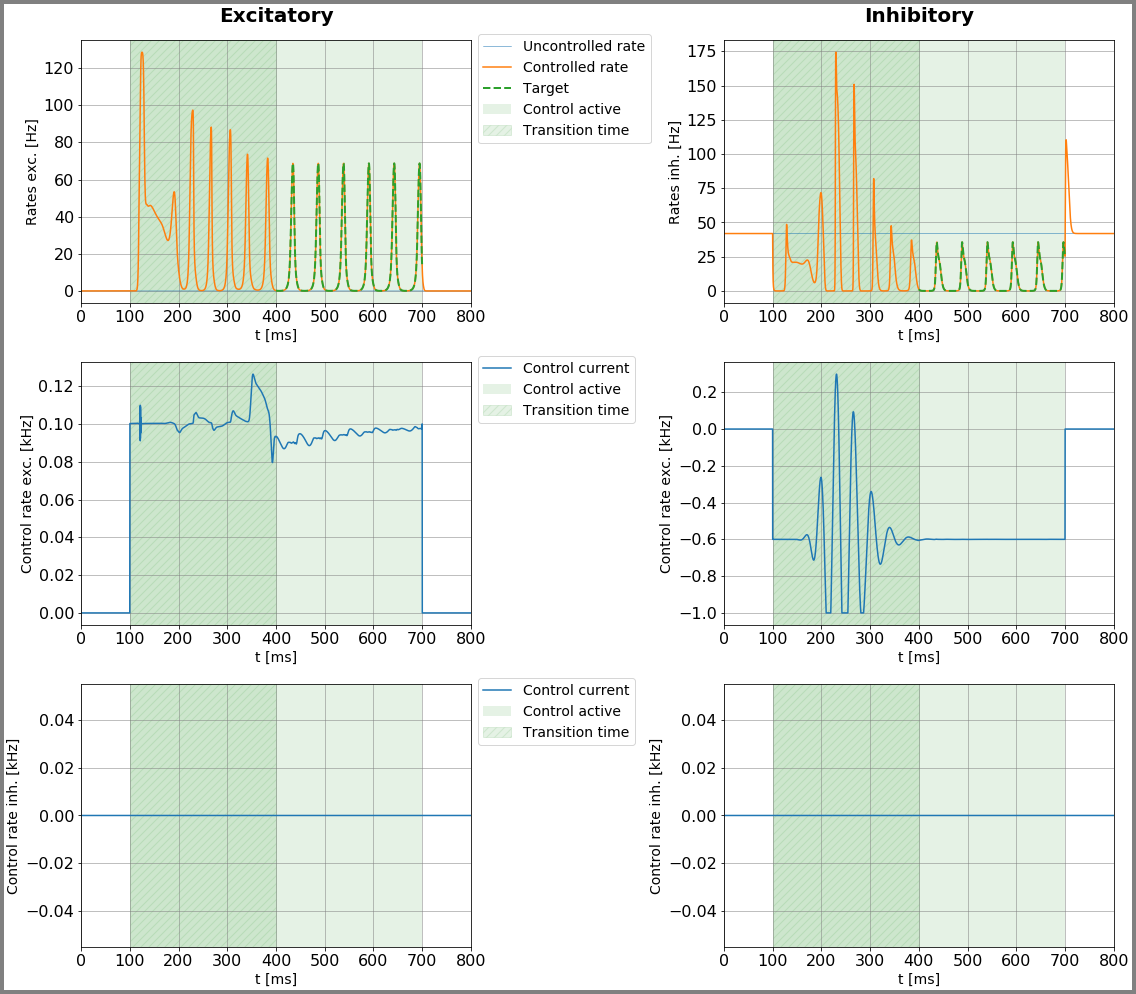

In [43]:
# A.6.a)
case_ind = 17
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,0,:] = 0.5
control0[0,1,:] = -3.
control2 = bestControla[:,:,n_pre-1:-n_post+1]

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]
cgv = "WYL"
max_it = 100

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)
    
bestControla, bestStatea, costa, runtimea, grada = aln.A1(control2, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
        min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
        control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
control input:  [0, 1] , precision measure:  [0, 1]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23.52688670541777
Gradient descend method:  None
RUN  1 , total integrated cost =  23.52654026978624
RUN  2 , total integrated cost =  23.52619267238972
RUN  3 , total integrated cost =  23.525835875318922
RUN  4 , total integrated cost =  23.525490313015066
RUN  5 , total integrated cost =  23.525130929239165
RUN  6 , total integrated cost =  23.524786701998135
RUN  7 , total integrated cost =  23.524427840718733
RUN  8 , total integrated cost =  23.524084628390202
RUN  9 , total integrated cost =  23.52373895264963
RUN  10 , total integrated cost =  23.523055547147266
RUN  11 , total integrated cost =  23.52242201425225
RUN  12 , total integrated cost =  23.52204204916482
RUN  13 , total integrated cost =  23.521677186642595
RUN  14 , total integrated cost =  23.52132012682648
RUN  15 , total integrated cost =  23.52095877008451
RUN  16 , total i

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  100 , total integrated cost =  23.490678147968108
RUN  100 , total integrated cost =  23.490678147968108
Improved over  100  iterations in  19.859928500000024  seconds by  0.1539028852522364  percent.
Problem in initial value trasfer:  Vmean_exc -80.81091189200119 -80.81091170625069
Problem in initial value trasfer:  Vmean_exc -56.76255884895424 -56.783285581814276
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23.490678147968108
Gradient descend method:  HS
RUN  1 , total integrated cost =  23.490321029498705
RUN  2 , total integrated cost =  23.478026642135106
RUN  3 , total integrated cost =  23.470035809494593
RUN  4 , total integrated cost =  23.465752614803314
RUN  5 , total integrated cost =  23.45891631758118
RUN  6 , total integrated cost =  23.442413970529337
RUN  7 , total integrated cost =  23.44217266433741
RUN  8 , total integrated cost =  23.43779119889982
RUN  9 , total integrated cost =  23.43540191778688
RUN  10 , total integrated cost = 

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  100 , total integrated cost =  23.055767162213126
RUN  100 , total integrated cost =  23.055767162213126
Improved over  100  iterations in  29.884029400000145  seconds by  1.8514194567541722  percent.
Problem in initial value trasfer:  Vmean_exc -80.81091189200119 -80.81091170625069
Problem in initial value trasfer:  Vmean_exc -56.76249082295737 -56.78323173421025
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23.055767162213126
Gradient descend method:  FR
RUN  1 , total integrated cost =  23.054949039480036
RUN  2 , total integrated cost =  23.053474782391696
RUN  3 , total integrated cost =  23.047298282519343
RUN  4 , total integrated cost =  23.042725452000827
RUN  5 , total integrated cost =  23.04171029856644
RUN  6 , total integrated cost =  23.041112848377065
RUN  7 , total integrated cost =  23.03998468629604
RUN  8 , total integrated cost =  23.039515994708157
RUN  9 , total integrated cost =  23.03908721009137
RUN  10 , total integrated cost = 

...

RUN  100 , total integrated cost =  21.04851992561123
RUN  100 , total integrated cost =  21.04851992561123
Improved over  100  iterations in  27.30270279999968  seconds by  0.937205893157838  percent.
Problem in initial value trasfer:  Vmean_exc -80.81091189200119 -80.81091170625069
Problem in initial value trasfer:  Vmean_exc -56.762667162192166 -56.7834399092784
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21.04851992561123
Gradient descend method:  HZ
RUN  1 , total integrated cost =  21.046626430126736
RUN  2 , total integrated cost =  21.042338355094678
RUN  3 , total integrated cost =  21.036621749768923
RUN  4 , total integrated cost =  21.036080335862877
RUN  5 , total integrated cost =  21.035765744718024
RUN  6 , total integrated cost =  21.03190403723352
RUN  7 , total integrated cost =  21.030253274811837
RUN  8 , total integrated cost =  21.028718238092388
RUN  9 , total integrated cost =  21.028210400760276
RUN  10 , total integrated cost =  21

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  100 , total integrated cost =  20.679735109385618
RUN  100 , total integrated cost =  20.679735109385618
Improved over  100  iterations in  26.96086110000033  seconds by  1.7520700625457692  percent.
Problem in initial value trasfer:  Vmean_exc -80.81091189200119 -80.81091170625069
Problem in initial value trasfer:  Vmean_exc -56.76286778487067 -56.78363997626394
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  20.679735109385618
Gradient descend method:  None
RUN  1 , total integrated cost =  20.674400242575505
RUN  2 , total integrated cost =  20.672650914076005
RUN  3 , total integrated cost =  20.672230733148478
RUN  4 , total integrated cost =  20.671851176064557
RUN  5 , total integrated cost =  20.671486641489828
RUN  6 , total integrated cost =  20.671135075356755
RUN  7 , total integrated cost =  20.67082496193105
RUN  8 , total integrated cost =  20.670502942960574
RUN  9 , total integrated cost =  20.670195950410513
RUN  10 , total integrated cost

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  100 , total integrated cost =  20.62745278096543
RUN  100 , total integrated cost =  20.62745278096543
Improved over  100  iterations in  20.49045380000007  seconds by  0.2528191398179871  percent.
Problem in initial value trasfer:  Vmean_exc -80.81091189200119 -80.81091170625069
Problem in initial value trasfer:  Vmean_exc -56.762695357707024 -56.78347568372308


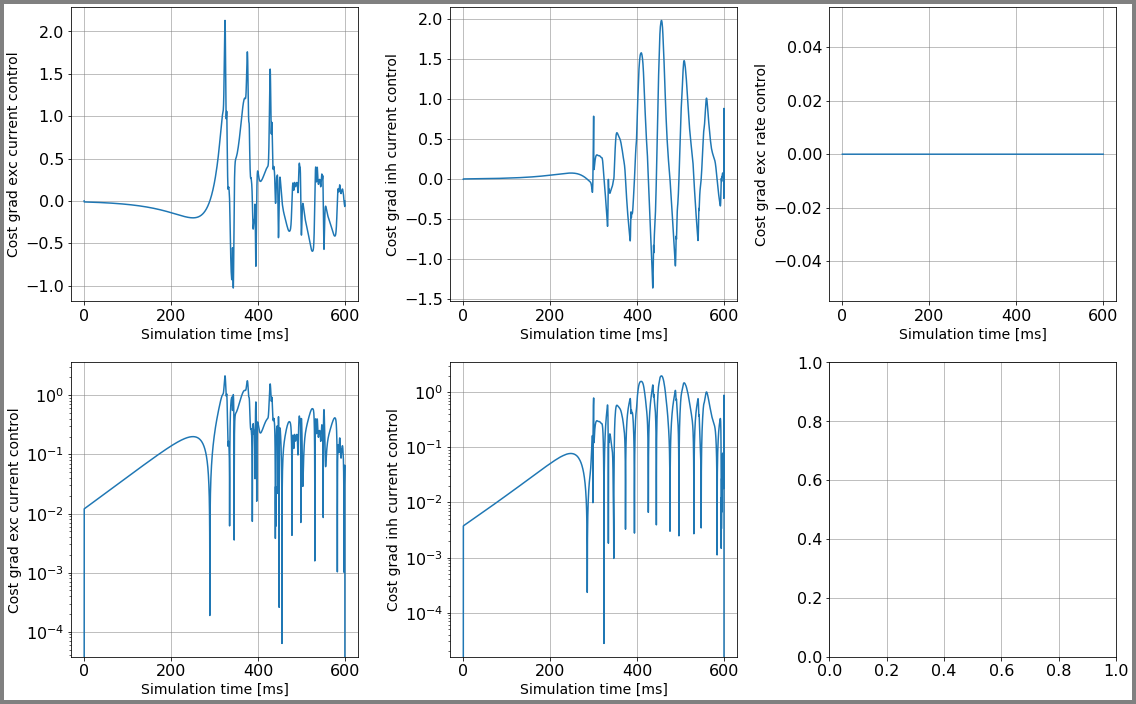

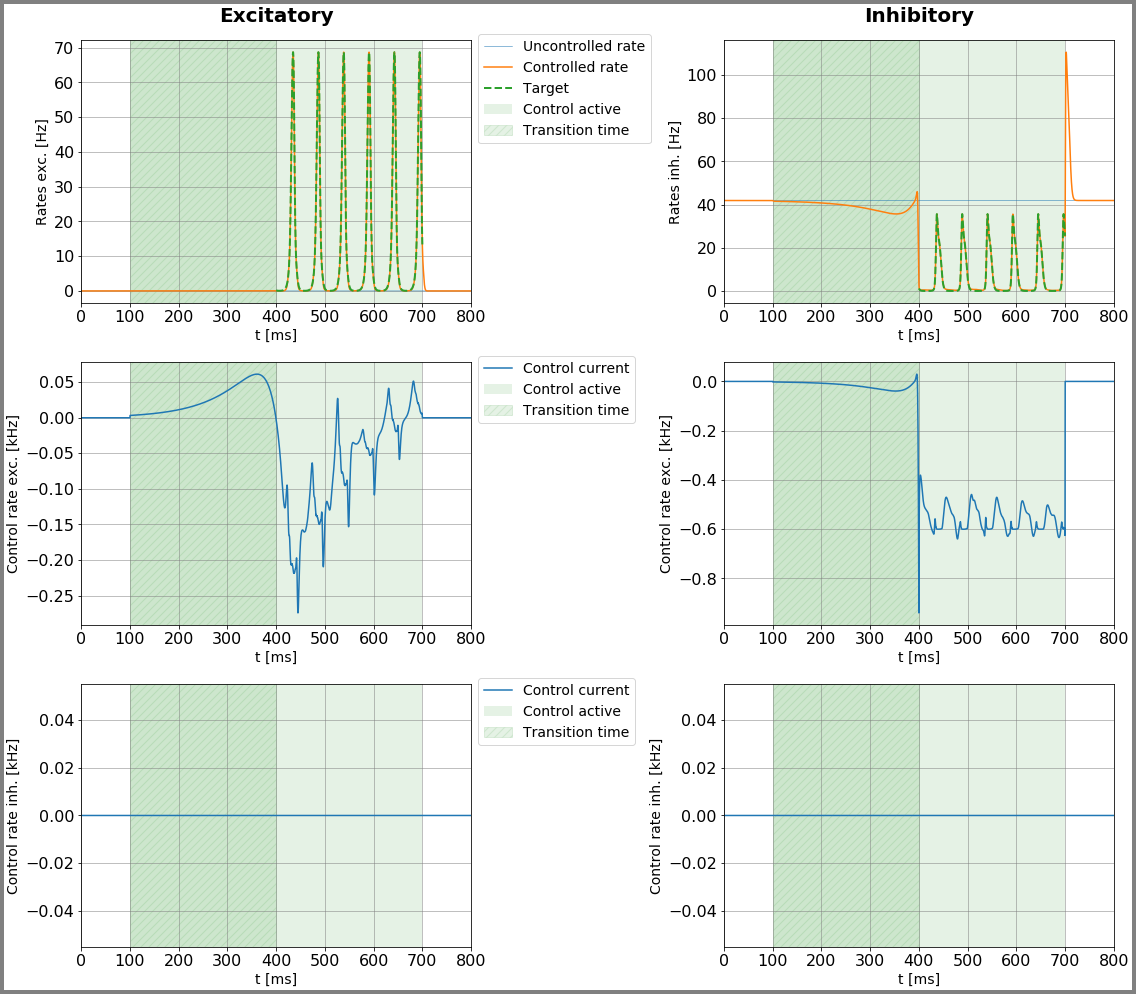

In [36]:
# A.6.a)
case_ind = 17
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]
cgv = "FR"
max_it = 100

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

for cgv in cgv_list:
    
    setinit(initVars)
    aln.params.duration = dur
    #control1 = bestControla[:,:,n_pre-1:-n_post+1]
    
    bestControla, bestStatea, costa, runtimea, grada = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
        min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
        control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9636.010238312652
Gradient descend method:  HS
RUN  1 , total integrated cost =  9636.009399352131
RUN  2 , total integrated cost =  9636.00469659493
RUN  3 , total integrated cost =  9636.004456692122
RUN  4 , total integrated cost =  9636.001944697098
RUN  5 , total integrated cost =  9636.000802876504
RUN  6 , total integrated cost =  9635.998981476052
RUN  7 , total integrated cost =  9635.998522056772
RUN  8 , total integrated cost =  9635.994664226851
RUN  9 , total integrated cost =  9635.994510866858
RUN  10 , total integrated cost =  9635.99070242307
RUN  11 , total integrated cost =  9635.990068894958
RUN  12 , total integrated cost =  9635.987446603453
RUN  13 , total integrated cost =  9635.986644741657
RUN  14 , total integrated cost =  9635.984635279709
RUN  15 , total integrated cost =  9635.984075581237
RUN  16 , total integrated cost =  9635.981039170889
RUN  17 , total integrated c

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  100 , total integrated cost =  9635.820336418556
RUN  100 , total integrated cost =  9635.820336418556
Improved over  100  iterations in  30.440582899999754  seconds by  0.0019707523072298727  percent.
Problem in initial value trasfer:  Vmean_exc -80.81091189200119 -80.81091170625069
Problem in initial value trasfer:  Vmean_exc -56.74753787116893 -56.765331826720264


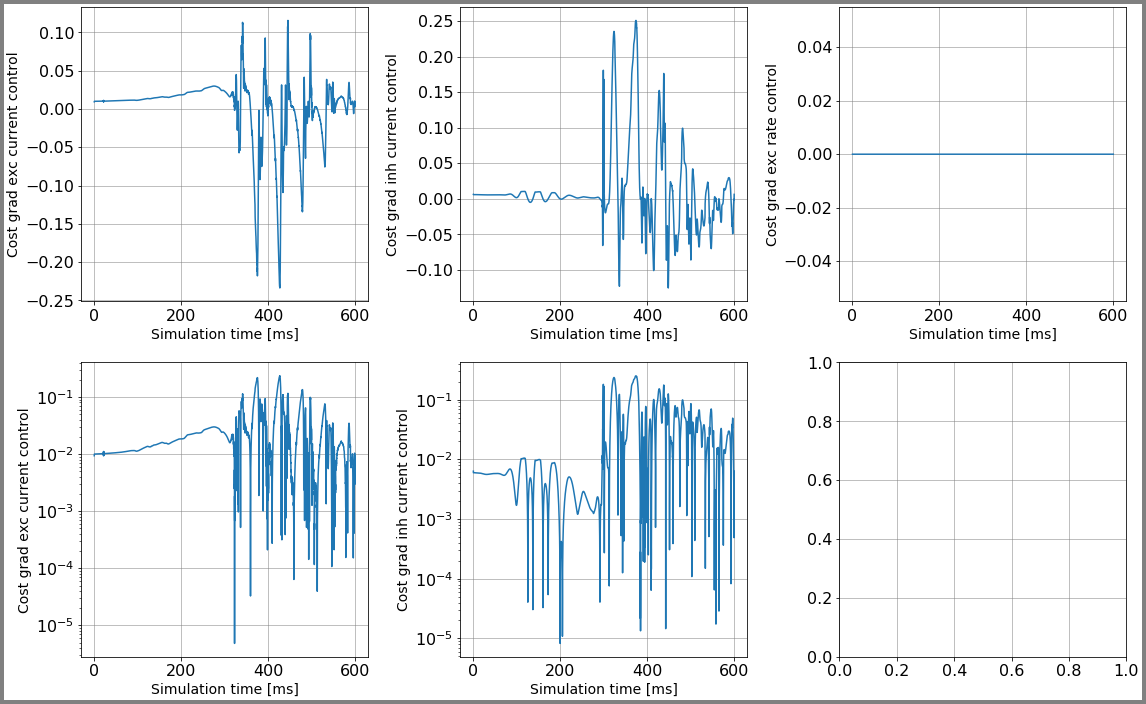

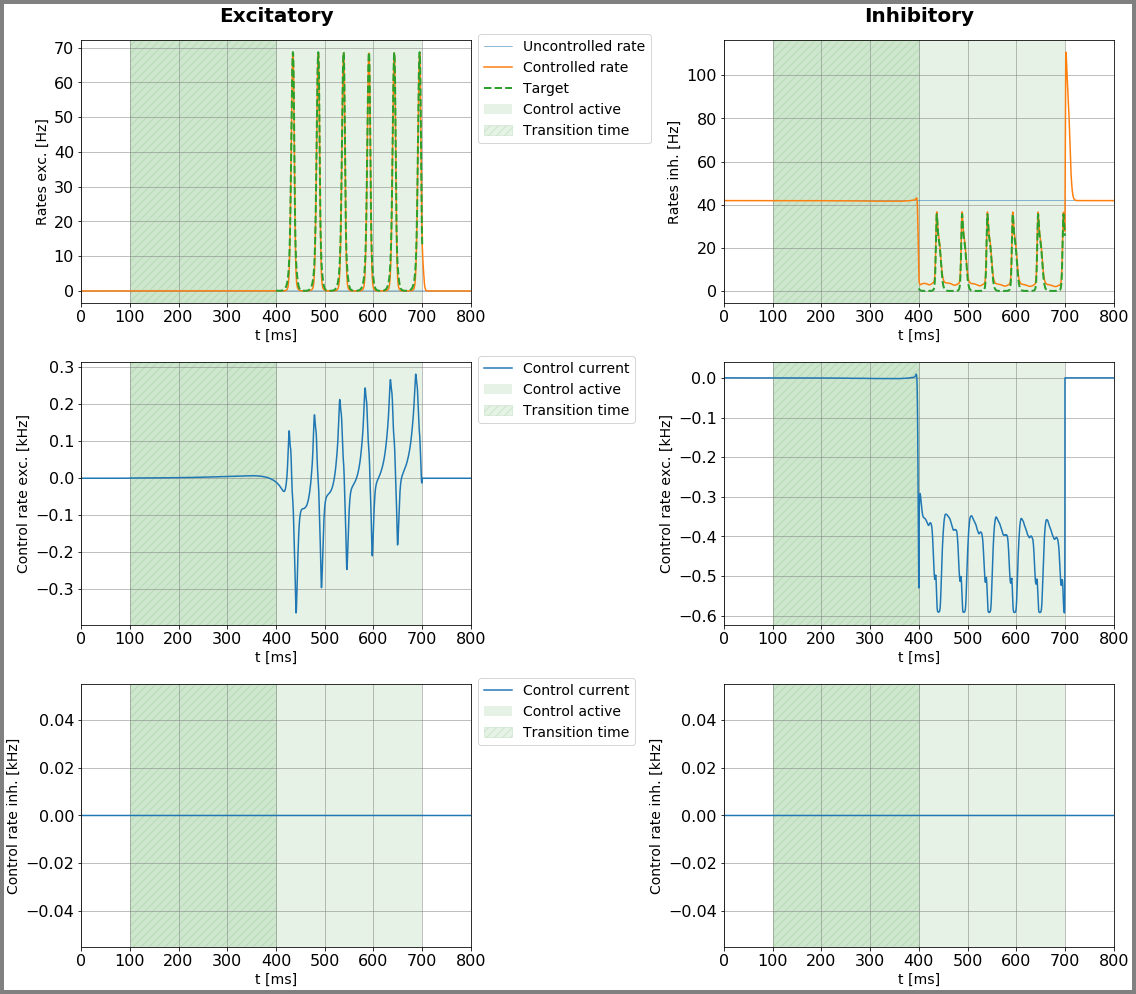

In [58]:
case_ind = 17
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 1e1, 1e1)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control3 = bestControla[:,:,n_pre-1:-n_post+1]
control4 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ"
cgv = "HS"

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control4, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 18

set cost params
control input:  [0, 2] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  81410.97810861089
RUN  1 , total integrated cost =  28220.93099366349
RUN  2 , total integrated cost =  8706.32167774579
RUN  3 , total integrated cost =  2942.1730867898946
RUN  4 , total integrated cost =  2055.3854158559902
RUN  5 , total integrated cost =  1758.7461694504257
RUN  6 , total integrated cost =  1592.0502502635104
RUN  7 , total integrated cost =  1470.0688329324387
RUN  8 , total integrated cost =  1370.7611869690013
RUN  9 , total integrated cost =  1288.4889763714507
RUN  10 , total integrated cost =  1217.0146462720222
RUN  11 , total integrated cost =  1156.1269947954322
RUN  12 , total integrated cost =  1098.9693667943407
RUN  13 , total integrated cost =  1052.3125832533897
RUN  14 , total integrated cost =  1012.967106903134
RUN  15 , total integrated cost =  978.9255538756918
RUN  16 , total integrated cost =  949.6227338166

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  5000 , total integrated cost =  22.98316590463019
RUN  5000 , total integrated cost =  22.98316590463019
Improved over  5000  iterations by  99.97176895986439  percent.
Problem in initial value trasfer:  Vmean_exc -80.81091189200119 -80.81091170625069
Problem in initial value trasfer:  Vmean_exc -56.72811595871975 -56.75798610843452


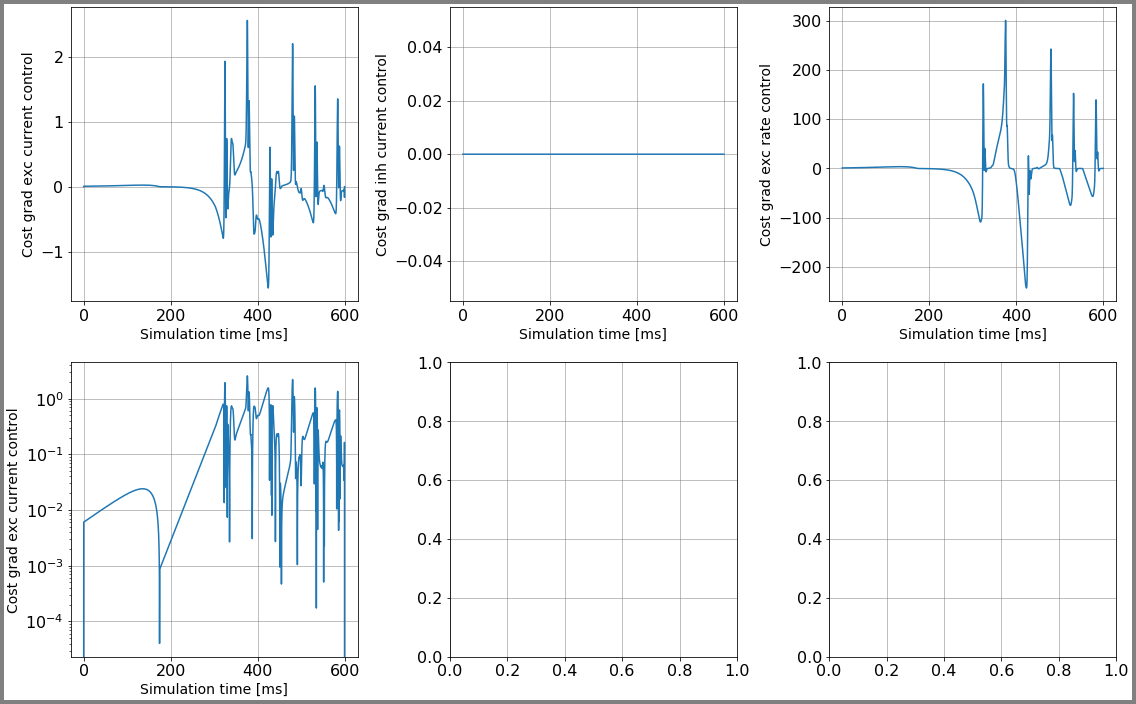

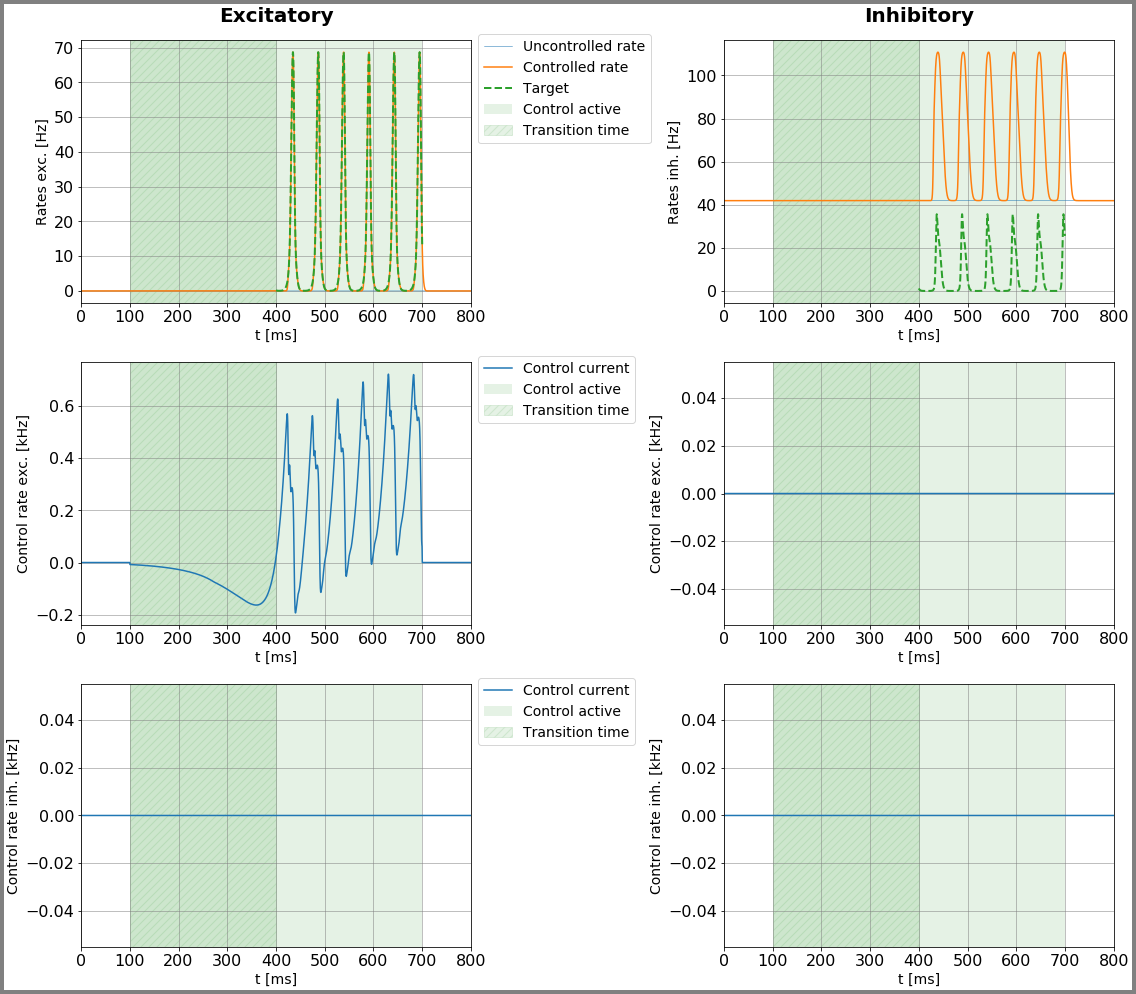

In [19]:
# A.8.a)
case_ind = 18
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  81410.97810861089
RUN  1 , total integrated cost =  64943.19587847938
RUN  2 , total integrated cost =  46295.61370022929
RUN  3 , total integrated cost =  31667.822312212378
RUN  4 , total integrated cost =  18080.37507179515
RUN  5 , total integrated cost =  8362.583758010735
RUN  6 , total integrated cost =  3103.1177937073044
RUN  7 , total integrated cost =  1216.1845020057
RUN  8 , total integrated cost =  647.8883295147992
RUN  9 , total integrated cost =  396.9795682435188
RUN  10 , total integrated cost =  280.2137420097986
RUN  11 , total integrated cost =  216.6694872382254
RUN  12 , total integrated cost =  178.98564760920206
RUN  13 , total integrated cost =  155.23554373494784
RUN  14 , total integrated cost =  138.94779045485961
RUN  15 , total integrated cost =  125.84435733947704
RUN  16 , total integrated cost =  115.47869698091762
RUN  17 , total integrated cost =  107.23632831498

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  5000 , total integrated cost =  0.3477773253024112
RUN  5000 , total integrated cost =  0.3477773253024112
Improved over  5000  iterations by  99.99957281274175  percent.
Problem in initial value trasfer:  Vmean_exc -80.81091189200119 -80.81091170625069
Problem in initial value trasfer:  Vmean_exc -56.72298650270497 -56.75664270807232


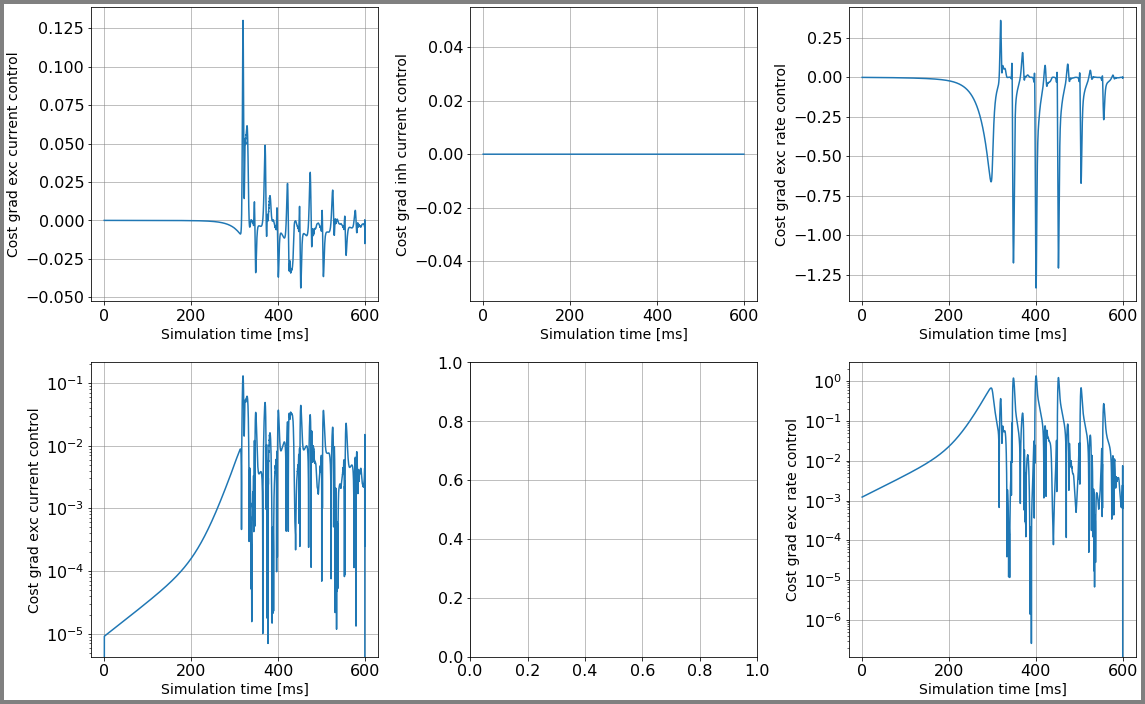

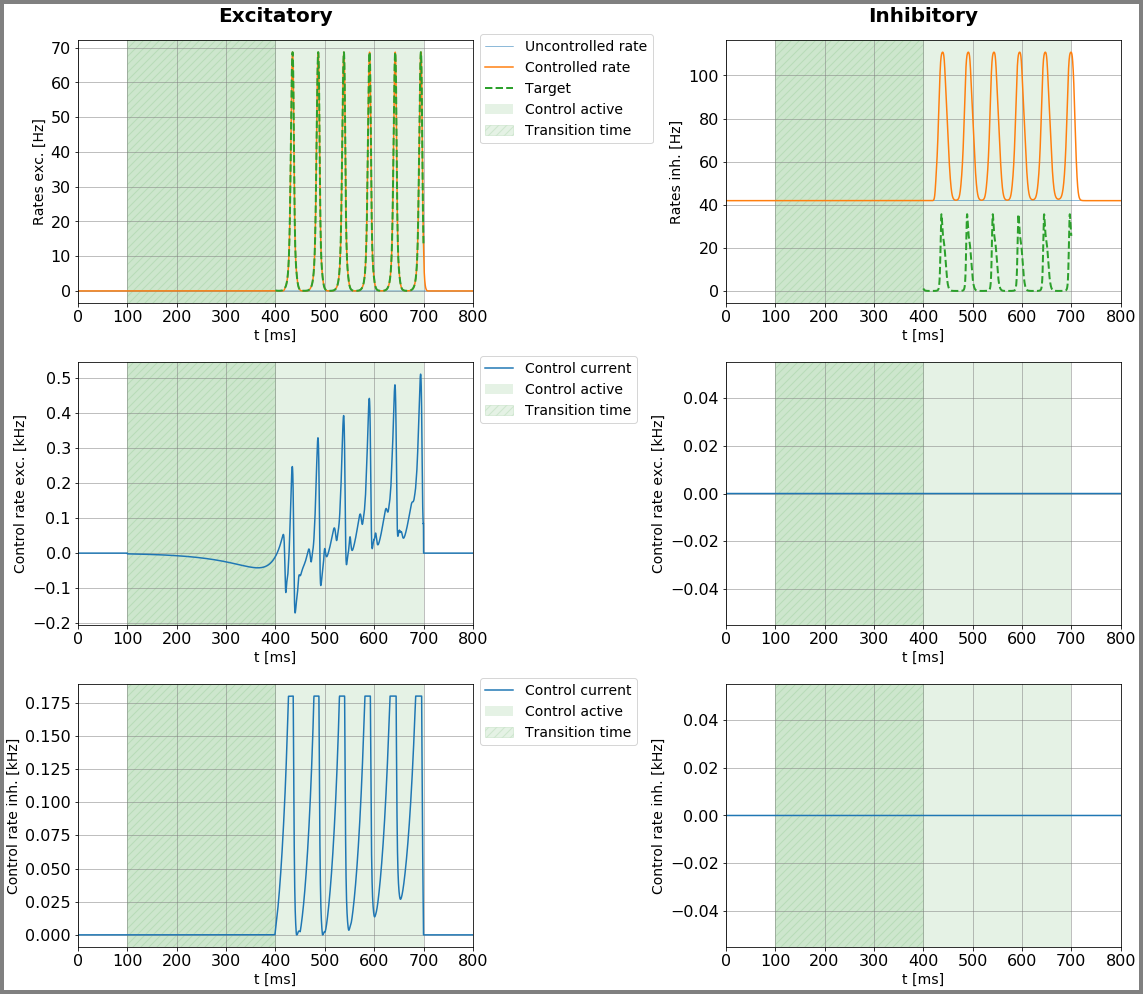

In [20]:
case_ind = 18
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 1e-4, 1e-4)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 19

In [ ]:
# A.10.a)
case_ind = 19
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

set cost params
control input:  [1, 2] , precision measure:  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  81410.97810861089
RUN  1 , total integrated cost =  64970.88204081282
RUN  2 , total integrated cost =  44808.21369623565
RUN  3 , total integrated cost =  36377.23869707592
RUN  4 , total integrated cost =  20754.182100419443
RUN  5 , total integrated cost =  6880.744105666618
RUN  6 , total integrated cost =  4798.169827628526
RUN  7 , total integrated cost =  4104.125763132695
RUN  8 , total integrated cost =  3342.5597037780067
RUN  9 , total integrated cost =  3136.306147146864
RUN  10 , total integrated cost =  2984.6122150528945
RUN  11 , total integrated cost =  2850.81482858041
RUN  12 , total integrated cost =  2717.307964252664
RUN  13 , total integrated cost =  2602.412984883199
RUN  14 , total integrated cost =  2486.8845144414813
RUN  15 , total integrated cost =  2380.57746095132
RUN  16 , total integrated cost =  2214.3614426585377
RUN

In [ ]:
case_ind = 19
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 1e-4, 1e-4)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

## 20

In [ ]:
# A.12.a)
case_ind = 20
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

trans_time = trans_time_array[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, transition_time_ = trans_time)#, separate_comp = True, crop_dir = 0., crop_t = [0,-1])

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )

In [ ]:
case_ind = 20
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 1e-4, 1e-4)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars,
    transition_time_ = trans_time ) #separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case, transition_time_ = trans_time )